# M4-B2 — Vision PCB Defect (binôme async)

Auteurs : `Joelle` × `JulienC` — Date : `08/07/2026`

**Conventions** :
- `random_state=42`
- Pas de `print` excessif
- `Co-authored-by:` sur les commits significatifs

In [4]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

sys.path.append('..')  # racine du repo → permet les imports « package » src.*
from src.load_data import CLASSES, get_dataloaders

DATA_DIR = Path('../data/pcb_defect_sample')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

Device : cpu


## 1. EDA dataset PCB (~1h binôme)

- Distribution des 7 classes (déséquilibre ?)
- Visualisation 7×3 subplot (3 exemples par classe)
- Notes : qualité d'image, variabilité intra-classe, ambiguïtés

Distribution des classes :
- ok: 300
- open: 300
- short: 300
- mousebite: 300
- spur: 300
- copper: 300
- pin_hole: 300


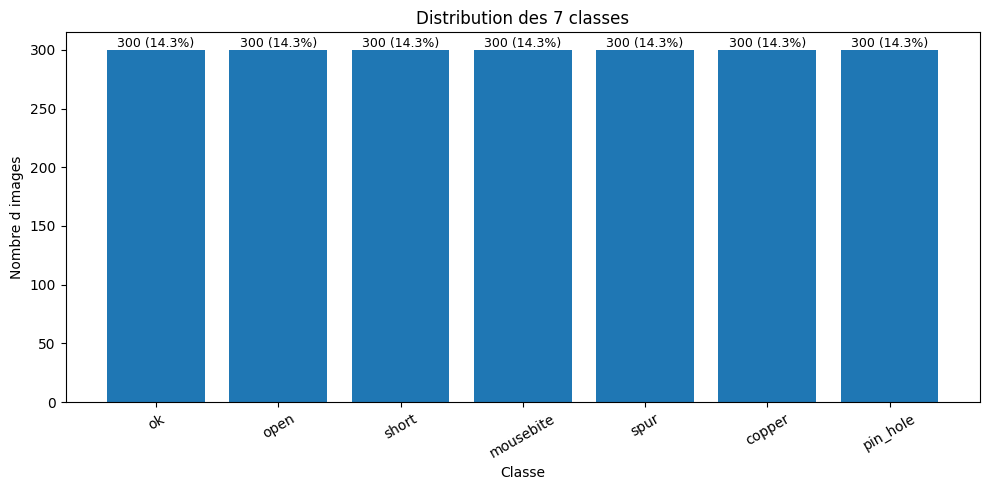

In [5]:
# TODO — distribution des classes
# from collections import Counter
# counts = Counter(...)

from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt

# Si CLASSES est deja importe depuis src.load_data, on le garde.
# Sinon, on detecte les classes depuis les sous-dossiers.
if "CLASSES" in globals():
    classes = list(CLASSES)
else:
    classes = sorted([p.name for p in Path(DATA_DIR).iterdir() if p.is_dir()])

valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

counts = Counter()
for cls in classes:
    class_dir = Path(DATA_DIR) / cls
    if class_dir.exists():
        counts[cls] = sum(
            1 for f in class_dir.iterdir()
            if f.is_file() and f.suffix.lower() in valid_ext
        )
    else:
        counts[cls] = 0

# Affichage texte
print("Distribution des classes :")
for cls in classes:
    print(f"- {cls}: {counts[cls]}")

# Bar chart
x = classes
y = [counts[c] for c in classes]
total = sum(y)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x, y)
ax.set_title("Distribution des 7 classes")
ax.set_xlabel("Classe")
ax.set_ylabel("Nombre d images")
ax.tick_params(axis="x", labelrotation=30)

# Annotations (nb + %)
for bar, n in zip(bars, y):
    pct = (n / total * 100) if total else 0
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{n} ({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

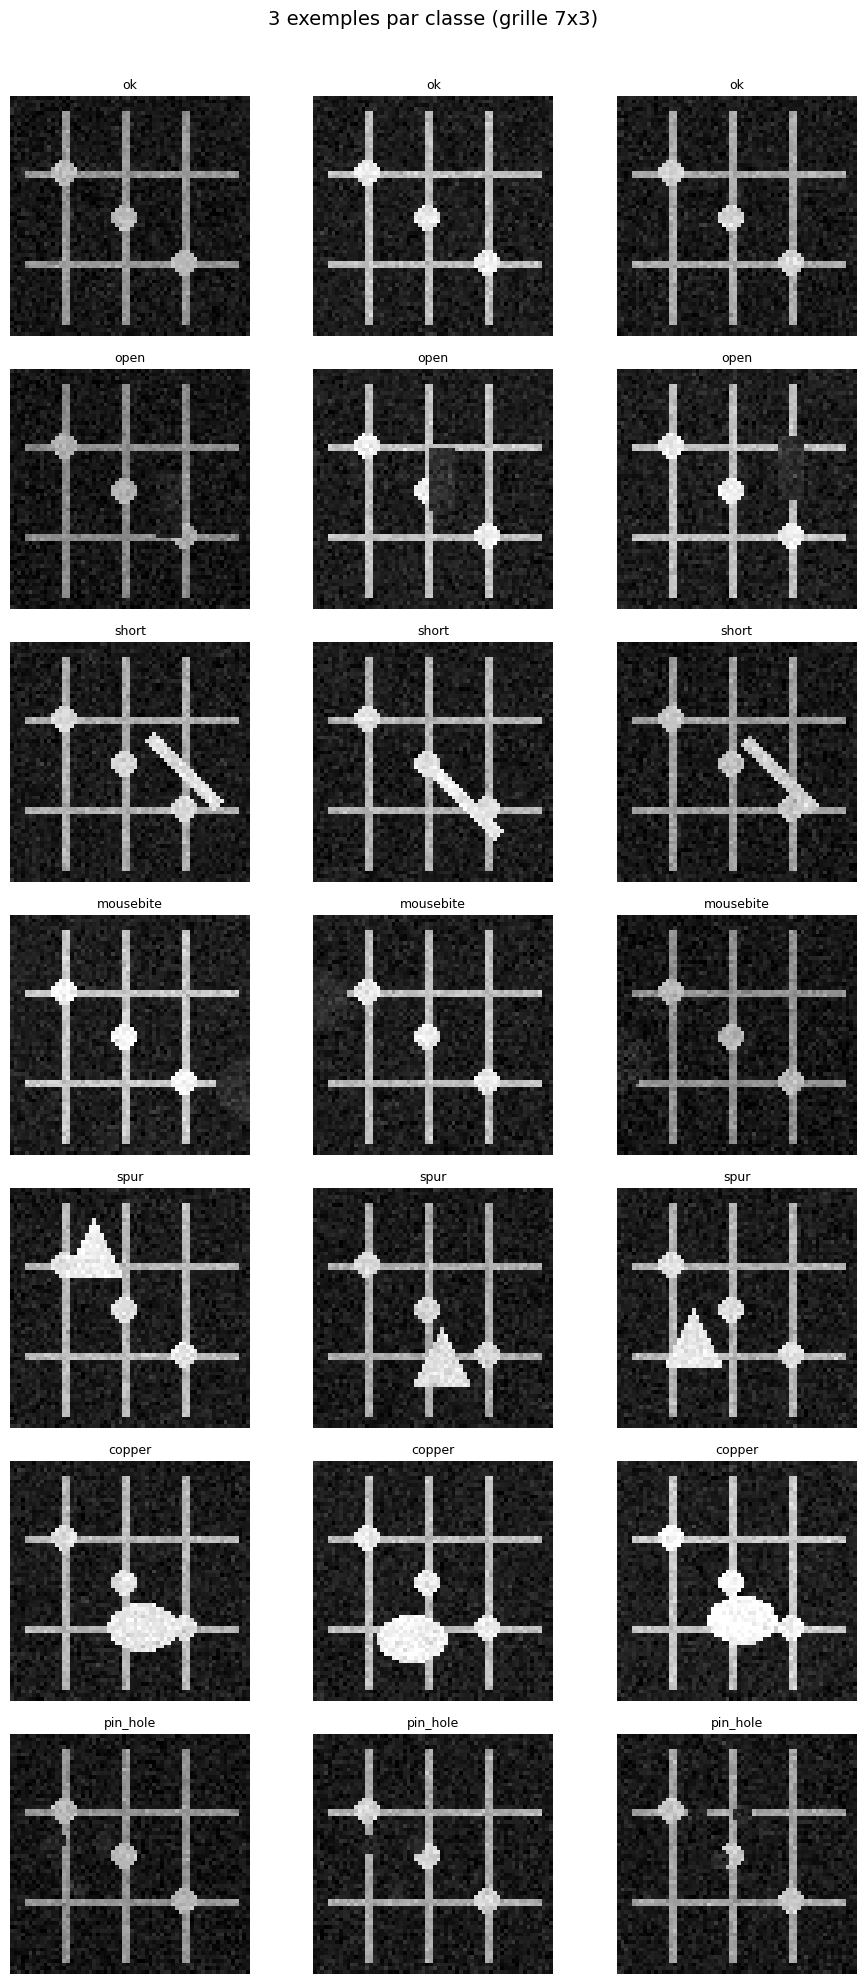

In [7]:
# TODO — 3 exemples par classe en grille 7×3

import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

random.seed(42)

# Si CLASSES existe deja, on l utilise.
# Sinon, on deduit les classes depuis les sous dossiers.
if "CLASSES" in globals():
    classes = list(CLASSES)
else:
    classes = sorted([p.name for p in Path(DATA_DIR).iterdir() if p.is_dir()])

valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

n_rows = len(classes)   # 7 classes
n_cols = 3              # 3 exemples par classe

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 2.8))
if n_rows == 1:
    axes = [axes]  # securite si un seul dossier classe

for i, cls in enumerate(classes):
    class_dir = Path(DATA_DIR) / cls
    images = []
    if class_dir.exists():
        images = [
            p for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in valid_ext
        ]

    # Si moins de 3 images, on complete avec des cases vides
    if len(images) >= n_cols:
        chosen = random.sample(images, n_cols)
    else:
        chosen = images + [None] * (n_cols - len(images))

    for j in range(n_cols):
        ax = axes[i][j] if n_rows > 1 else axes[j]
        ax.axis("off")

        img_path = chosen[j]
        if img_path is None:
            ax.set_title(f"{cls} | vide", fontsize=9)
            continue

        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{cls}", fontsize=9)

plt.suptitle("3 exemples par classe (grille 7x3)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. Implémentation de l'option choisie (~4h binôme)

Cf. `decisions.md` pour le choix (A / B / C).

- Option A : `src/option_a_cnn.py`
- Option B : `src/option_b_transfer.py`
- Option C : `src/option_c_clip.py`

In [ ]:
# TODO — entraîner ou inférer l'option choisie
# Import : from src.option_a_cnn import SimpleCNN, train_one_epoch, evaluate  (idem b/c)
# Mesure : temps train (si options A ou B), latence inférence (toutes options), accuracy

## 3. Comparaison économique 3 approches (~1h30)

Voir `economic_comparison.md` à remplir.

## 4. Verdict + préparation restitution duo (~1h30)

- `verdict.md` : recommandation, 8 lignes max
- Préparation restitution mardi 1ᵉʳ sept (rentrée M5) : qui dit quoi ?